# QQQ (Invesco QQQ Trust)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import warnings

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "QQQ_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2008-06-26,0.383134,0.371755,0.378410,0.374925,0.008330,"(0.38, 0.4]","(0.36, 0.38]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
1,2008-06-27,0.417735,0.405422,0.376642,0.373039,0.021524,"(0.4, 0.42]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(0.0182, 0.0364]"
2,2008-06-30,0.423834,0.411633,0.378878,0.373956,0.018044,"(0.42, 0.44]","(0.4, 0.42]","(0.36, 0.38]","(0.36, 0.38]","(-0.002, 0.0182]"
3,2008-07-01,0.365257,0.362851,0.342444,0.364032,0.055530,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.36, 0.38]","(0.0545, 0.0727]"
4,2008-07-02,0.374496,0.364824,0.356799,0.347692,0.079141,"(0.36, 0.38]","(0.36, 0.38]","(0.34, 0.36]","(0.34, 0.36]","(0.0727, 0.0909]"


# 3D Analysis

#### Matplotlib

Scatter plot

In [3]:
import matplotlib
print("Current Matplotlib backend:", matplotlib.get_backend())

Current Matplotlib backend: module://matplotlib_inline.backend_inline


In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.switch_backend('TkAgg')

In [5]:
# ============================
# (Interactive)
# ============================

# Create the figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')  # Add a 3D subplot

# Scatter plot using Open, Close, and Volume columns
scatter = ax.scatter(
    categorized_df['Open'], 
    categorized_df['Close'], 
    categorized_df['Volume'], 
    c=categorized_df['Volume'],  # Color points based on Volume
    cmap='viridis',  # Use the Viridis colormap
    alpha=0.7,  # Set transparency for the points
    depthshade=False  # Ensure compatibility with newer versions
)

# Add title and axis labels
ax.set_title("3D Scatter Plot: Open, Close, Volume")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("Volume")

# Add a colorbar to represent Volume values
plt.colorbar(scatter, label="Volume")

plt.show(block=True)

C:\Users\niush\AppData\Local\Temp\ipykernel_12404\3938632146.py:10: MatplotlibDeprecationWarning: The clean function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use none, you no longer need to clean a Grouper instead.
  scatter = ax.scatter(


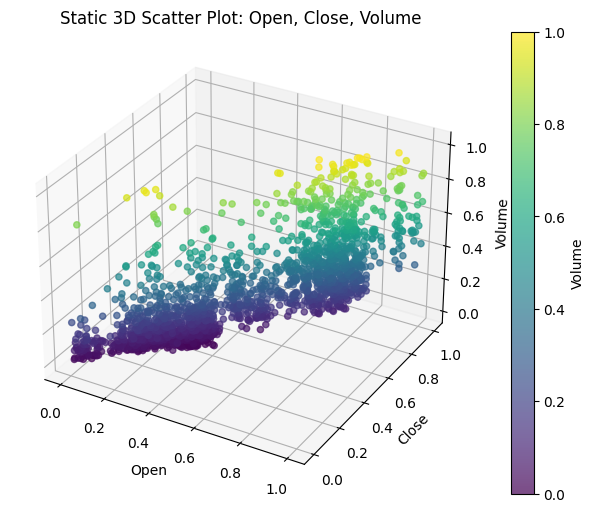

In [6]:
# ============================
# (Static)
# ============================

# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# Enable inline plotting
%matplotlib inline

plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')
scatter = ax_static.scatter(
    categorized_df['Open'], 
    categorized_df['Close'], 
    categorized_df['Volume'], 
    c=categorized_df['Volume'], 
    cmap='viridis', 
    alpha=0.7
)
ax_static.set_title("Static 3D Scatter Plot: Open, Close, Volume")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("Volume")
plt.colorbar(scatter, label="Volume")
plt.show()

Dot Pattern:

The dots are displayed in a scatter pattern on the chart, with volume represented by color.
Lighter colors (yellow and green) indicate higher volumes, while darker colors (blue and purple) indicate lower volumes.
Key Observations:

It seems that as the Open and Close prices increase, the Volume also tends to increase.
Most of the dots with lower volume are located in the lower parts of the chart (lower Open and Close), while high volumes are mainly seen in the parts with higher Open and Close.
The scatter indicates that there is a correlation between Open and Close and volume, but other factors may also be at play.
Correlation Analysis:

The data on the chart appears to be positive, meaning that the Open and Close prices are directly related to the Volume.
But the scatter of the points indicates that the relationship is not completely linear and that other factors may also be at play.

Static 3d surface

In [7]:
# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# making the data ready for Surface Plot
x = np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 30)
y = np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 30)
x, y = np.meshgrid(x, y)
# z = (x + y) / 2

def volume_to_price_ratio(volume, price):
    """
    Calculates the volume to price ratio.
    
    Args:
        volume (float): The trading volume.
        price (float): The price of the asset.
        
    Returns:
        float: The volume to price ratio.
    """
    return volume / price

z = np.zeros_like(x)
for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        open_price = x[i, j]
        close_price = y[i, j]
        volume = categorized_df['Volume'].iloc[i * x.shape[1] + j]
        # average of price
        z[i, j] = volume_to_price_ratio(volume, (open_price + close_price) / 2)

# ============================
# (Interactive)
# ============================

# Enable backend for opening plots in a separate window
plt.switch_backend('TkAgg')

# Create the interactive figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surface = ax.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.8)

# Add title and axis labels
ax.set_title("Interactive 3D Surface Plot: Open, Close")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("Volume / avg(open,close)")

# Add a colorbar to represent Z values
fig.colorbar(surface, ax=ax, label="Z Value")

# Display the interactive plot
plt.show(block=True)

C:\Users\niush\AppData\Local\Temp\ipykernel_12404\4152897988.py:21: RuntimeWarning: divide by zero encountered in scalar divide
  return volume / price
c:\Users\niush\anaconda3\lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:180: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


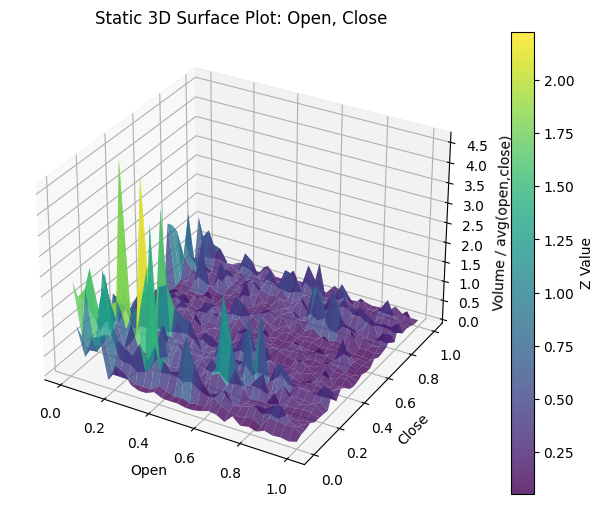

In [8]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot in the cell
plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')

# Plot surface
surface_static = ax_static.plot_surface(x, y, z, cmap='viridis', edgecolor='none', alpha=0.8)

# Add title and axis labels
ax_static.set_title("Static 3D Surface Plot: Open, Close")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("Volume / avg(open,close)")

# Add a colorbar to represent Z values
plt.colorbar(surface_static, label="Z Value")

# Show the static plot in the cell
plt.show()

Volume to Price Ratio </br>
Calculating Volume to Closing Price Ratio</br>
z = Volume / Close

Volatility pattern: The chart has strong and complex fluctuations, indicating a turbulent and volatile market for this asset.

In [9]:
# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# making the data ready for Surface Plot
x = np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 30)
y = np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 30)
x, y = np.meshgrid(x, y)
z = ((y - x) / x) * 100


# ============================
# (Interactive)
# ============================

# Enable backend for opening plots in a separate window
plt.switch_backend('TkAgg')

# Create the interactive figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surface = ax.plot_surface(x, y, z, cmap='coolwarm', edgecolor='none', alpha=0.8)

# Add title and axis labels
ax.set_title("Interactive 3D Surface Plot: Open, Close")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("(Open - Close) percentage")

# Add a colorbar to represent Z values
fig.colorbar(surface, ax=ax, label="Z Value")

# Display the interactive plot
plt.show(block=True)

C:\Users\niush\AppData\Local\Temp\ipykernel_12404\3328066581.py:8: RuntimeWarning: divide by zero encountered in divide
  z = ((y - x) / x) * 100
C:\Users\niush\AppData\Local\Temp\ipykernel_12404\3328066581.py:8: RuntimeWarning: invalid value encountered in divide
  z = ((y - x) / x) * 100
c:\Users\niush\anaconda3\lib\site-packages\mpl_toolkits\mplot3d\proj3d.py:180: RuntimeWarning: invalid value encountered in divide
  txs, tys, tzs = vecw[0]/w, vecw[1]/w, vecw[2]/w


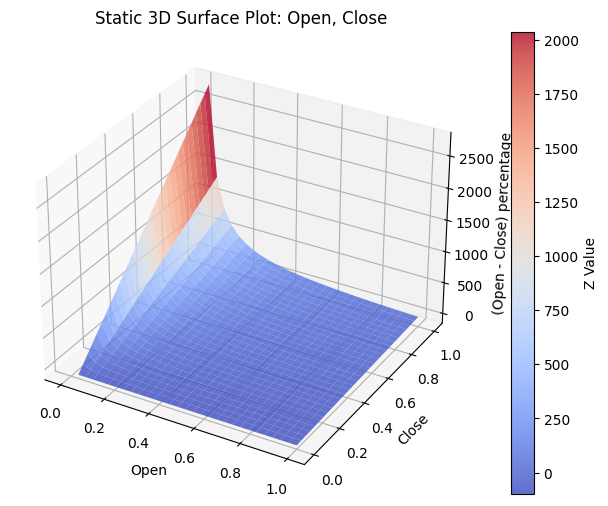

In [10]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot in the cell
plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')

# Plot surface
surface_static = ax_static.plot_surface(x, y, z, cmap='coolwarm', edgecolor='none', alpha=0.8)

# Add title and axis labels
ax_static.set_title("Static 3D Surface Plot: Open, Close")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("(Open - Close) percentage")

# Add a colorbar to represent Z values
plt.colorbar(surface_static, label="Z Value")

# Show the static plot in the cell
plt.show()

Because the z-axis in this 3D chart is the percentage change in price (Open - Close), this chart can be used to identify and extract a variety of patterns.</br></br></br>

Price Patterns:
Uptrends/Downtrends: These patterns can be identified from the price chart over time (x and y axes). When the price is consistently moving up or down, this pattern is shown.

Triangle Patterns: These patterns are seen in parts of the chart where the price is enclosed in a range and moving towards a point. This pattern shows that the price is stabilizing before moving in one direction.

Head and Shoulders Patterns: These patterns are seen in parts of the chart where the price forms a head and two shoulders pattern. This pattern usually indicates a reversal trend and can predict a future downtrend.</br></br></br>

Support and Resistance Levels:
These levels are seen in parts of the chart where prices are less volatile. Support levels are points where prices usually stop and then rise, and resistance levels are points where prices usually stop and then fall.</br></br></br>

Reversal patterns:
These patterns are seen in areas of the chart where there are sudden changes from positive to negative in the percentage change in price (z-axis). These sudden changes can indicate reversal patterns that may be predictive of future price changes.

3D Bar Plot

In [11]:
# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# Making the input ready for 3d bar plot
x = np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 10)
y = np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 10)
x, y = np.meshgrid(x, y)
z = np.zeros_like(x)
dz = np.random.randint(100, 1000, size=x.shape)  # height data

# ============================
# (Interactive)
# ============================

# Enable backend for opening plots in a separate window
plt.switch_backend('TkAgg')

# Create the interactive figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')

# Plot 3D Bar
for i in range(len(x)):
    ax.bar3d(x[i], y[i], z[i], dx=0.1, dy=0.1, dz=dz[i], color='teal', alpha=0.7)

# Add title and axis labels
ax.set_title("Interactive 3D Bar Plot: Open vs Close vs Volume")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("Volume")

# Display the interactive plot
plt.show(block=True)

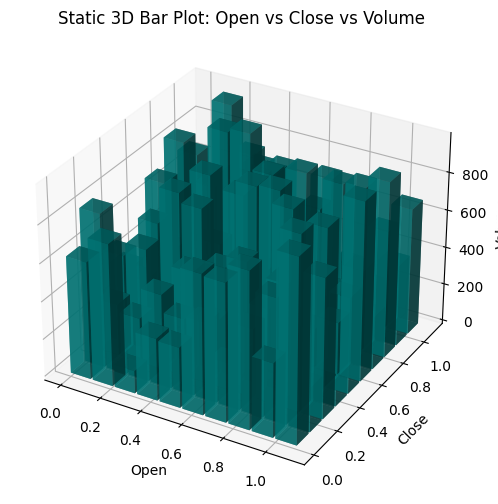

In [12]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot in the cell
plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')

# Plot 3D Bar
for i in range(len(x)):
    ax_static.bar3d(x[i], y[i], z[i], dx=0.1, dy=0.1, dz=dz[i], color='teal', alpha=0.7)

# Add title and axis labels
ax_static.set_title("Static 3D Bar Plot: Open vs Close vs Volume")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("Volume")

# Show the static plot in the cell
plt.show()

Triangular Surface Plot

In [13]:
# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# Making data ready for Triangular Surface Plot
x = categorized_df['Open'].sample(100, random_state=42)  # choosing samples of Open
y = categorized_df['Close'].sample(100, random_state=42)  # choosing samples of Close
z = categorized_df['Volume'].sample(100, random_state=42)  # choosing samples of Volume

# ============================
# (Interactive)
# ============================

# Enable backend for opening plots in a separate window
plt.switch_backend('TkAgg')

# Create the interactive figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')

# making Triangulation
tri = Triangulation(x, y)
ax.plot_trisurf(x, y, z, triangles=tri.triangles, cmap='viridis', alpha=0.8)

# Add title and axis labels
ax.set_title("Interactive 3D Triangular Surface Plot: Open vs Close vs Volume")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("Volume")

# Display the interactive plot
plt.show(block=True)

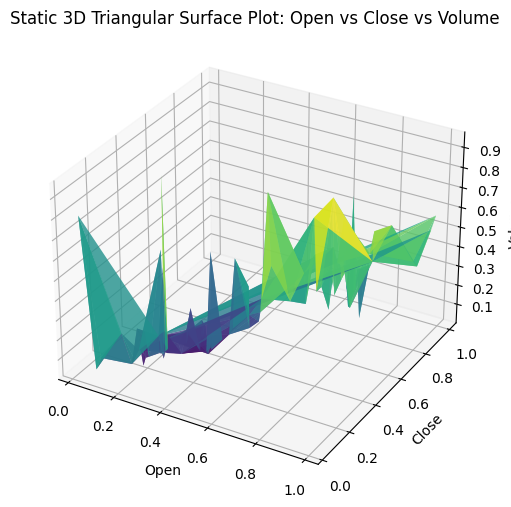

In [14]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot in the cell
plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')

# Create a Triangulation
tri_static = Triangulation(x, y)
ax_static.plot_trisurf(x, y, z, triangles=tri_static.triangles, cmap='viridis', alpha=0.8)

# Add title and axis labels
ax_static.set_title("Static 3D Triangular Surface Plot: Open vs Close vs Volume")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("Volume")

# Show the static plot in the cell
plt.show()

Streamlines Plot

In [15]:
# Ignore deprecation warnings from Matplotlib
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

# Making data ready for Streamlines Plot
x, y, z = np.meshgrid(
    np.linspace(categorized_df['Open'].min(), categorized_df['Open'].max(), 10),
    np.linspace(categorized_df['Close'].min(), categorized_df['Close'].max(), 10),
    np.linspace(categorized_df['Volume'].min(), categorized_df['Volume'].max(), 10)
)

u = np.sin(np.pi * x / x.max())
v = np.cos(np.pi * y / y.max())
w = np.sin(np.pi * z / z.max())

# ============================
# (Interactive)
# ============================

# Enable backend for opening plots in a separate window
plt.switch_backend('TkAgg')

# Create the interactive figure
fig = plt.figure(figsize=(8, 6))  # Set the initial size of the window
ax = fig.add_subplot(111, projection='3d')

# draw the flow of lines
ax.quiver(x, y, z, u, v, w, length=0.05, normalize=True, color='blue', alpha=0.6)

# Add title and axis labels
ax.set_title("Interactive 3D Streamlines Plot: Open vs Close vs Volume")
ax.set_xlabel("Open")
ax.set_ylabel("Close")
ax.set_zlabel("Volume")

# Display the interactive plot
plt.show(block=True)

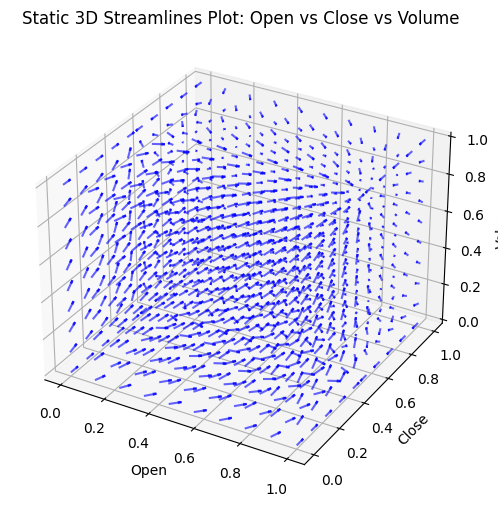

In [16]:
# ============================
# (Static)
# ============================

# Enable inline plotting
%matplotlib inline

# Create the static plot in the cell
plt.figure(figsize=(10, 6))
ax_static = plt.axes(projection='3d')

# drawing 
ax_static.quiver(x, y, z, u, v, w, length=0.05, normalize=True, color='blue', alpha=0.6)

# Add title and axis labels
ax_static.set_title("Static 3D Streamlines Plot: Open vs Close vs Volume")
ax_static.set_xlabel("Open")
ax_static.set_ylabel("Close")
ax_static.set_zlabel("Volume")

# Show the static plot in the cell
plt.show()

On the X and Y axes, if the surface structure of the chart is smoother, it indicates a higher correlation between the Open and Close.

High volume values ​​(yellow color) are usually seen at certain points, indicating that trading volume is higher in these intervals.

In this chart, higher height (Z) and yellow color usually indicate high trading volume at a particular point.
Points with lower Open and Close values ​​(bottom left) may have low trading volume (cooler colors such as blue or green).